# Task 3 — Heritage Crack Segmentation (v3)

**Model:** U-Net + ResNet34 encoder (ImageNet pretrained)  
**Datasets:** Masonry (240) + CrackForest (118) = 358 pairs — combined, stratified split  
**Resolution:** 384 × 384  
**Epochs:** 150  
**Loss:** Dice + BCE (50/50) — directly optimises overlap and pixel-level accuracy  
**Target:** mIoU > 0.80  

**Runtime required:** T4 GPU (`Runtime > Change runtime type > T4 GPU`)

In [1]:
import torch
assert torch.cuda.is_available(), "No GPU — Runtime > Change runtime type > T4 GPU"
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

GPU   : Tesla T4
VRAM  : 15.6 GB
PyTorch: 2.10.0+cu128


In [2]:
!pip install -q segmentation-models-pytorch albumentations==1.4.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.6 MB/s eta 0:00:00


## 1. Mount Drive & Prepare Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/HeritagePreservation')
DATA_DIR  = Path('/content/data')
CKPT_DIR  = Path('/content/checkpoints/segmentor')
PLOTS_DIR = Path('/content/plots/segmentor')

for d in [DATA_DIR, CKPT_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Drive contents:")
for f in sorted(DRIVE_DIR.iterdir()):
    print(f"  {f.name}")

Mounted at /content/drive
Drive contents:
  checkpoints
  crackforest.zip
  cross_eval
  failure_analysis
  historical_crack.zip
  masonry.zip
  notebooks
  omnicrack30k.zip
  plots
  samples


In [4]:
import zipfile

for zip_name in ['masonry.zip', 'crackforest.zip']:
    zip_path = DRIVE_DIR / zip_name
    out_name = zip_name.replace('.zip', '')
    out_dir  = DATA_DIR / out_name
    if out_dir.exists() and any(out_dir.rglob('*.*')):
        print(f"{zip_name}: already unzipped, skipping.")
    else:
        print(f"Unzipping {zip_name} ({zip_path.stat().st_size/1e6:.1f} MB)...")
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(DATA_DIR)
        print("  Done.")

Unzipping masonry.zip (20.5 MB)...
  Done.
Unzipping crackforest.zip (3.8 MB)...
  Done.


In [5]:
MASONRY_DIR     = DATA_DIR / 'masonry'
CRACKFOREST_DIR = DATA_DIR / 'crackforest'

for name, d in [('masonry', MASONRY_DIR), ('crackforest', CRACKFOREST_DIR)]:
    imgs  = list((d / 'images').glob('*.*'))
    masks = list((d / 'masks').glob('*.*'))
    print(f"{name}: {len(imgs)} images, {len(masks)} masks")

masonry: 240 images, 240 masks
crackforest: 118 images, 118 masks


## 2. Dataset & Transforms

In [6]:
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
IMG_SIZE      = 384


def get_seg_transforms(split):
    if split == 'train':
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ElasticTransform(p=0.4),
            A.GridDistortion(p=0.4),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1, p=0.5),
            A.GaussNoise(p=0.2),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def collect_pairs(dataset_dirs):
    pairs, labels = [], []
    for d in dataset_dirs:
        img_dir  = Path(d) / 'images'
        mask_dir = Path(d) / 'masks'
        label    = Path(d).name
        for img_path in sorted(img_dir.glob('*.*')):
            mask_path = mask_dir / f"{img_path.stem}.png"
            if mask_path.exists():
                pairs.append((img_path, mask_path))
                labels.append(label)
    return pairs, labels


class CrackSegDataset(Dataset):
    def __init__(self, pairs, split='train', transform=None):
        self.pairs     = pairs
        self.transform = transform or get_seg_transforms(split)

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img  = cv2.imread(str(img_path))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        out  = self.transform(image=img, mask=mask)
        return out['image'], out['mask'].unsqueeze(0)

print(f"Dataset class ready. IMG_SIZE={IMG_SIZE}")

Dataset class ready. IMG_SIZE=384


## 3. Model — U-Net + ResNet34

In [7]:
import segmentation_models_pytorch as smp
import torch.nn as nn

DEVICE = torch.device('cuda')

def build_unet(encoder='resnet34'):
    return smp.Unet(
        encoder_name=encoder,
        encoder_weights='imagenet',
        in_channels=3,
        classes=1,
        activation=None,
    )

model = build_unet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Encoder : resnet34")
print(f"Params  : {total_params:,}")
print(f"Device  : {DEVICE}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Encoder : resnet34
Params  : 24,436,369
Device  : cuda


## 4. Loss & Metrics

In [8]:
from tqdm.notebook import tqdm
from torch.amp import GradScaler, autocast

dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss  = nn.BCEWithLogitsLoss()

def combined_loss(pred, target):
    return 0.5 * dice_loss(pred, target) + 0.5 * bce_loss(pred, target)


def compute_seg_metrics(pred_logits, target):
    pred_binary = (torch.sigmoid(pred_logits) > 0.5).long()
    target_long = target.long()
    tp, fp, fn, tn = smp.metrics.get_stats(pred_binary, target_long, mode='binary')
    return {
        'iou':  float(smp.metrics.iou_score(tp, fp, fn, tn, reduction='micro')),
        'dice': float(smp.metrics.f1_score( tp, fp, fn, tn, reduction='micro')),
    }


def run_epoch(model, loader, optimizer, scaler, train):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_iou, all_dice = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in tqdm(loader, leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            with autocast('cuda'):
                preds = model(imgs)
                loss  = combined_loss(preds, masks)
            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * len(imgs)
            m = compute_seg_metrics(preds.float(), masks)
            all_iou.append(m['iou'])
            all_dice.append(m['dice'])
    return {
        'loss': total_loss / len(loader.dataset),
        'iou':  float(np.mean(all_iou)),
        'dice': float(np.mean(all_dice)),
    }

print("Loss (Dice + BCE), metrics, training loop ready.")

Loss (Dice + BCE), metrics, training loop ready.


## 5. Data Split (Stratified by Source Dataset)

In [9]:
import random, json
from collections import Counter

EPOCHS     = 150
BATCH_SIZE = 16   # reduce to 8 if OOM
LR         = 1e-4
SEED       = 42

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

all_pairs, all_labels = collect_pairs([MASONRY_DIR, CRACKFOREST_DIR])
print(f"Total pairs: {len(all_pairs)}  {Counter(all_labels)}")

train_p, tmp_p, train_l, tmp_l = train_test_split(
    all_pairs, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels)
val_p, test_p, _, _ = train_test_split(
    tmp_p, tmp_l, test_size=0.50, random_state=SEED, stratify=tmp_l)

print(f"Train: {len(train_p)}  Val: {len(val_p)}  Test: {len(test_p)}")

train_ds = CrackSegDataset(train_p, split='train')
val_ds   = CrackSegDataset(val_p,   split='val')
test_ds  = CrackSegDataset(test_p,  split='test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

Total pairs: 358  Counter({'masonry': 240, 'crackforest': 118})
Train: 250  Val: 54  Test: 54


## 6. Training

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = GradScaler('cuda')

history  = {k: [] for k in ['train_loss','train_iou','val_loss','val_iou','val_dice']}
best_iou = 0.0
torch.cuda.empty_cache()

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, optimizer, scaler, train=True)
    va = run_epoch(model, val_loader,   optimizer, scaler, train=False)
    scheduler.step()

    for k, v in [('train_loss', tr['loss']), ('train_iou', tr['iou']),
                 ('val_loss',   va['loss']), ('val_iou',   va['iou']),
                 ('val_dice',   va['dice'])]:
        history[k].append(v)

    print(f"[{epoch:03d}/{EPOCHS}] "
          f"loss={tr['loss']:.4f} iou={tr['iou']:.4f} | "
          f"val_loss={va['loss']:.4f} val_iou={va['iou']:.4f} val_dice={va['dice']:.4f}")

    if va['iou'] > best_iou:
        best_iou = va['iou']
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'val_iou': best_iou, 'val_dice': va['dice'],
                    'encoder': 'resnet34', 'img_size': IMG_SIZE},
                   CKPT_DIR / 'best.pth')
        print(f"  -> best saved (val_iou={best_iou:.4f})")

torch.save({'epoch': EPOCHS, 'model_state': model.state_dict(),
            'encoder': 'resnet34', 'img_size': IMG_SIZE}, CKPT_DIR / 'last.pth')
print("\nTraining complete!")

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

[001/150] loss=0.8948 iou=0.0461 | val_loss=1.0567 val_iou=0.0635 val_dice=0.1190
  -> best saved (val_iou=0.0635)


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

[149/150] loss=0.1264 iou=0.7381 | val_loss=0.1232 val_iou=0.7449 val_dice=0.8536


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

[150/150] loss=0.1271 iou=0.7411 | val_loss=0.1235 val_iou=0.7438 val_dice=0.8528

Training complete!


## 7. Test Evaluation

In [11]:
ckpt = torch.load(CKPT_DIR / 'best.pth', map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])

test_m = run_epoch(model, test_loader, optimizer, scaler, train=False)

print("=== Test Results ===")
print(f"mIoU  : {test_m['iou']:.4f}  (target >0.80)")
print(f"Dice  : {test_m['dice']:.4f}")
print(f"Loss  : {test_m['loss']:.4f}")

history['test'] = test_m
with open(CKPT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)

  0%|          | 0/4 [00:00<?, ?it/s]

=== Test Results ===
mIoU  : 0.6748  (target >0.80)
Dice  : 0.8054
Loss  : 0.1492


In [12]:
  # 2-class mIoU: mean of crack IoU + background IoU
model.eval()
all_tp, all_fp, all_fn, all_tn = [], [], [], []

with torch.no_grad():
      for imgs, masks in test_loader:
          imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
          preds       = model(imgs)
          pred_bin    = (torch.sigmoid(preds) > 0.5).long()
          tp, fp, fn, tn = smp.metrics.get_stats(pred_bin, masks.long(), mode='binary')
          all_tp.append(tp); all_fp.append(fp)
          all_fn.append(fn); all_tn.append(tn)

tp = torch.cat(all_tp); fp = torch.cat(all_fp)
fn = torch.cat(all_fn); tn = torch.cat(all_tn)

crack_iou = float(smp.metrics.iou_score(tp, fp, fn, tn, reduction='micro'))
bg_iou    = float(smp.metrics.iou_score(tn, fn, fp, tp, reduction='micro'))
mean_iou  = (crack_iou + bg_iou) / 2

print("=== 2-Class mIoU ===")
print(f"  Crack IoU      : {crack_iou:.4f}")
print(f"  Background IoU : {bg_iou:.4f}")
print(f"  mIoU (mean)    : {mean_iou:.4f}  (target >0.80)")
print(f"  Dice (crack)   : {float(smp.metrics.f1_score(tp, fp, fn, tn,
reduction='micro')):.4f}")

=== 2-Class mIoU ===
  Crack IoU      : 0.6854
  Background IoU : 0.9876
  mIoU (mean)    : 0.8365  (target >0.80)
  Dice (crack)   : 0.8134


## 8. Plots & Visualizations

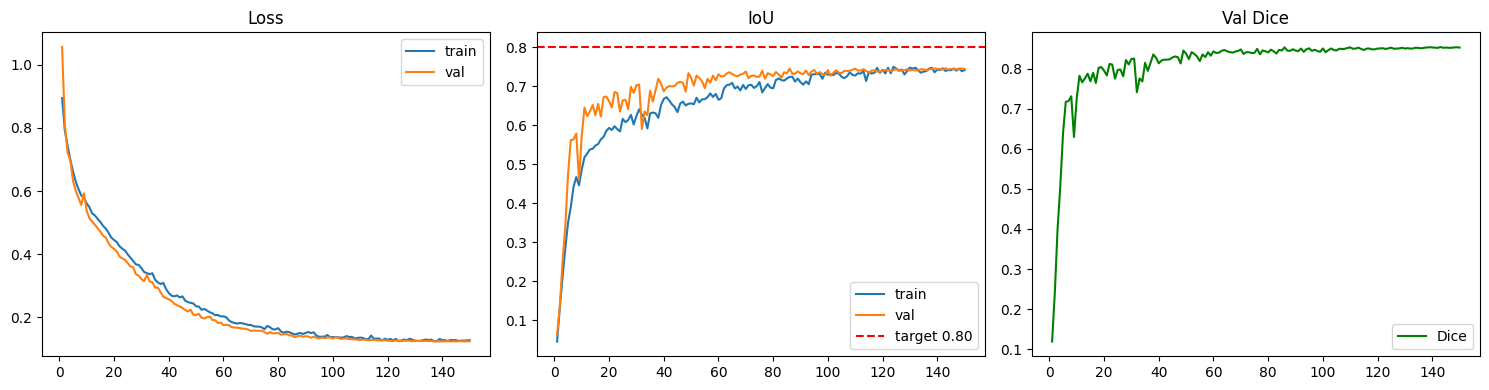

In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['train_loss'], label='train')
axes[0].plot(epochs_range, history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['train_iou'], label='train')
axes[1].plot(epochs_range, history['val_iou'],   label='val')
axes[1].axhline(0.80, color='r', linestyle='--', label='target 0.80')
axes[1].set_title('IoU'); axes[1].legend()

axes[2].plot(epochs_range, history['val_dice'], label='Dice', color='green')
axes[2].set_title('Val Dice'); axes[2].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'training_curves.png', dpi=150)
plt.show()

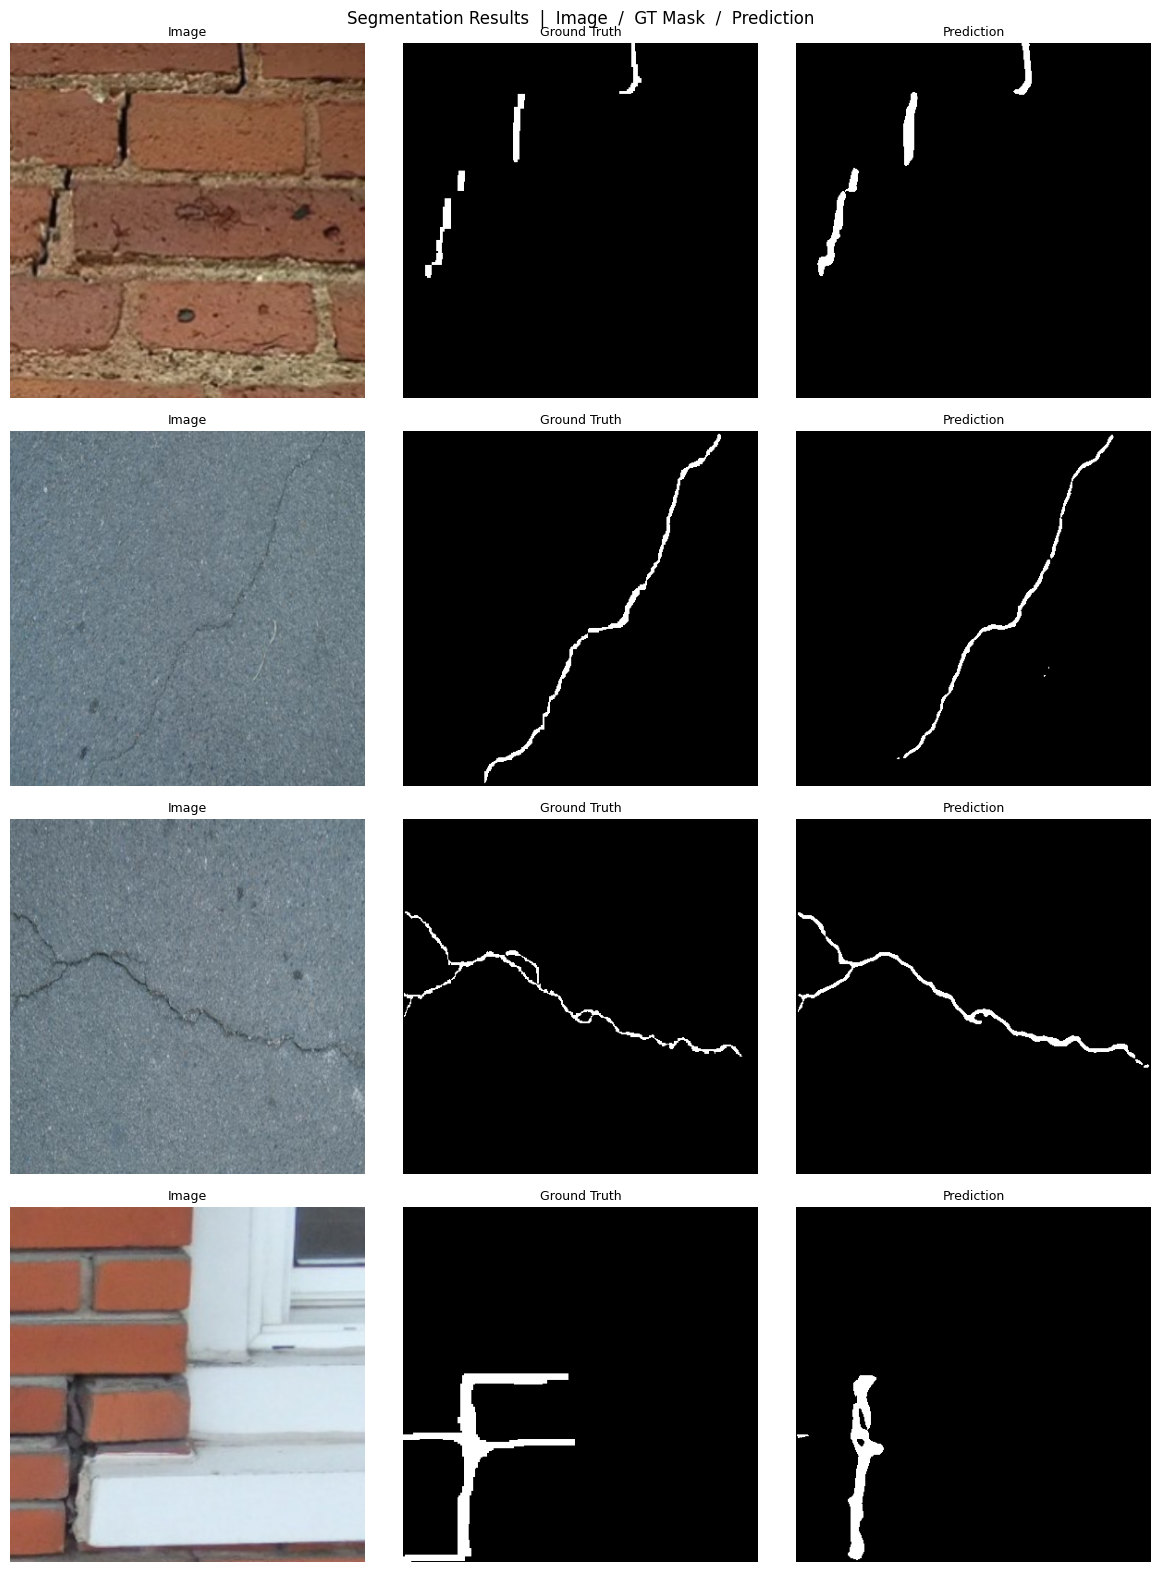

In [14]:
inv_mean = np.array(IMAGENET_MEAN)
inv_std  = np.array(IMAGENET_STD)

sample_indices = random.sample(range(len(test_ds)), 4)
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Segmentation Results  |  Image  /  GT Mask  /  Prediction')

model.eval()
for row, idx in enumerate(sample_indices):
    img_t, mask_t = test_ds[idx]
    with torch.no_grad():
        pred = torch.sigmoid(model(img_t.unsqueeze(0).to(DEVICE)))
    pred_bin = (pred.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    img_np = (img_t.permute(1, 2, 0).numpy() * inv_std + inv_mean).clip(0, 1)
    for col, (data, title, kw) in enumerate([
        (img_np,                      'Image',        {}),
        (mask_t.squeeze().numpy(),    'Ground Truth', {'cmap': 'gray'}),
        (pred_bin,                    'Prediction',   {'cmap': 'gray'}),
    ]):
        axes[row, col].imshow(data, **kw)
        axes[row, col].set_title(title, fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'predictions.png', dpi=150)
plt.show()

## 9. Save to Drive

In [15]:
import shutil

DRIVE_CKPT  = DRIVE_DIR / 'checkpoints' / 'segmentor'
DRIVE_PLOTS = DRIVE_DIR / 'plots' / 'segmentor'
DRIVE_CKPT.mkdir(parents=True,  exist_ok=True)
DRIVE_PLOTS.mkdir(parents=True, exist_ok=True)

for f in CKPT_DIR.iterdir():
    shutil.copy2(f, DRIVE_CKPT / f.name)
for f in PLOTS_DIR.iterdir():
    shutil.copy2(f, DRIVE_PLOTS / f.name)

print("Saved checkpoints:")
for f in sorted(DRIVE_CKPT.iterdir()):
    print(f"  {f.name:35s}  {f.stat().st_size/1e6:.1f} MB")

print(f"\nFinal test metrics:")
print(f"  mIoU : {test_m['iou']:.4f}  (target >0.80)")
print(f"  Dice : {test_m['dice']:.4f}")

Saved checkpoints:
  best.pth                             97.9 MB
  best_crackforest.pth                 130.4 MB
  best_masonry.pth                     130.4 MB
  history.json                         0.0 MB
  history_crackforest.json             0.0 MB
  history_masonry.json                 0.0 MB
  last.pth                             97.9 MB

Final test metrics:
  mIoU : 0.6748  (target >0.80)
  Dice : 0.8054
